数据维度： (6551, 30)

字段：
Index(['paper_id', 'title', 'abstract', 'publication_year', 'doi', 'journal',
       'cited_by_count', 'citation_percentile', 'recent_citations',
       'is_highly_cited', 'is_oa', 'authors', 'authors_count', 'institutions',
       'institutions_count', 'countries', 'countries_count',
       'international_collab', 'multi_institution', 'concepts',
       'concepts_count', 'topics', 'topics_count', 'title_length',
       'abstract_length', 'referenced_works_count', 'title_clean',
       'abstract_clean', 'title_processed', 'abstract_processed'],
      dtype='str')

缺失值统计：
countries             947
institutions          942
journal               306
authors                58
abstract_processed      8
title_processed         4
doi                     1
dtype: int64


<Figure size 1200x600 with 0 Axes>

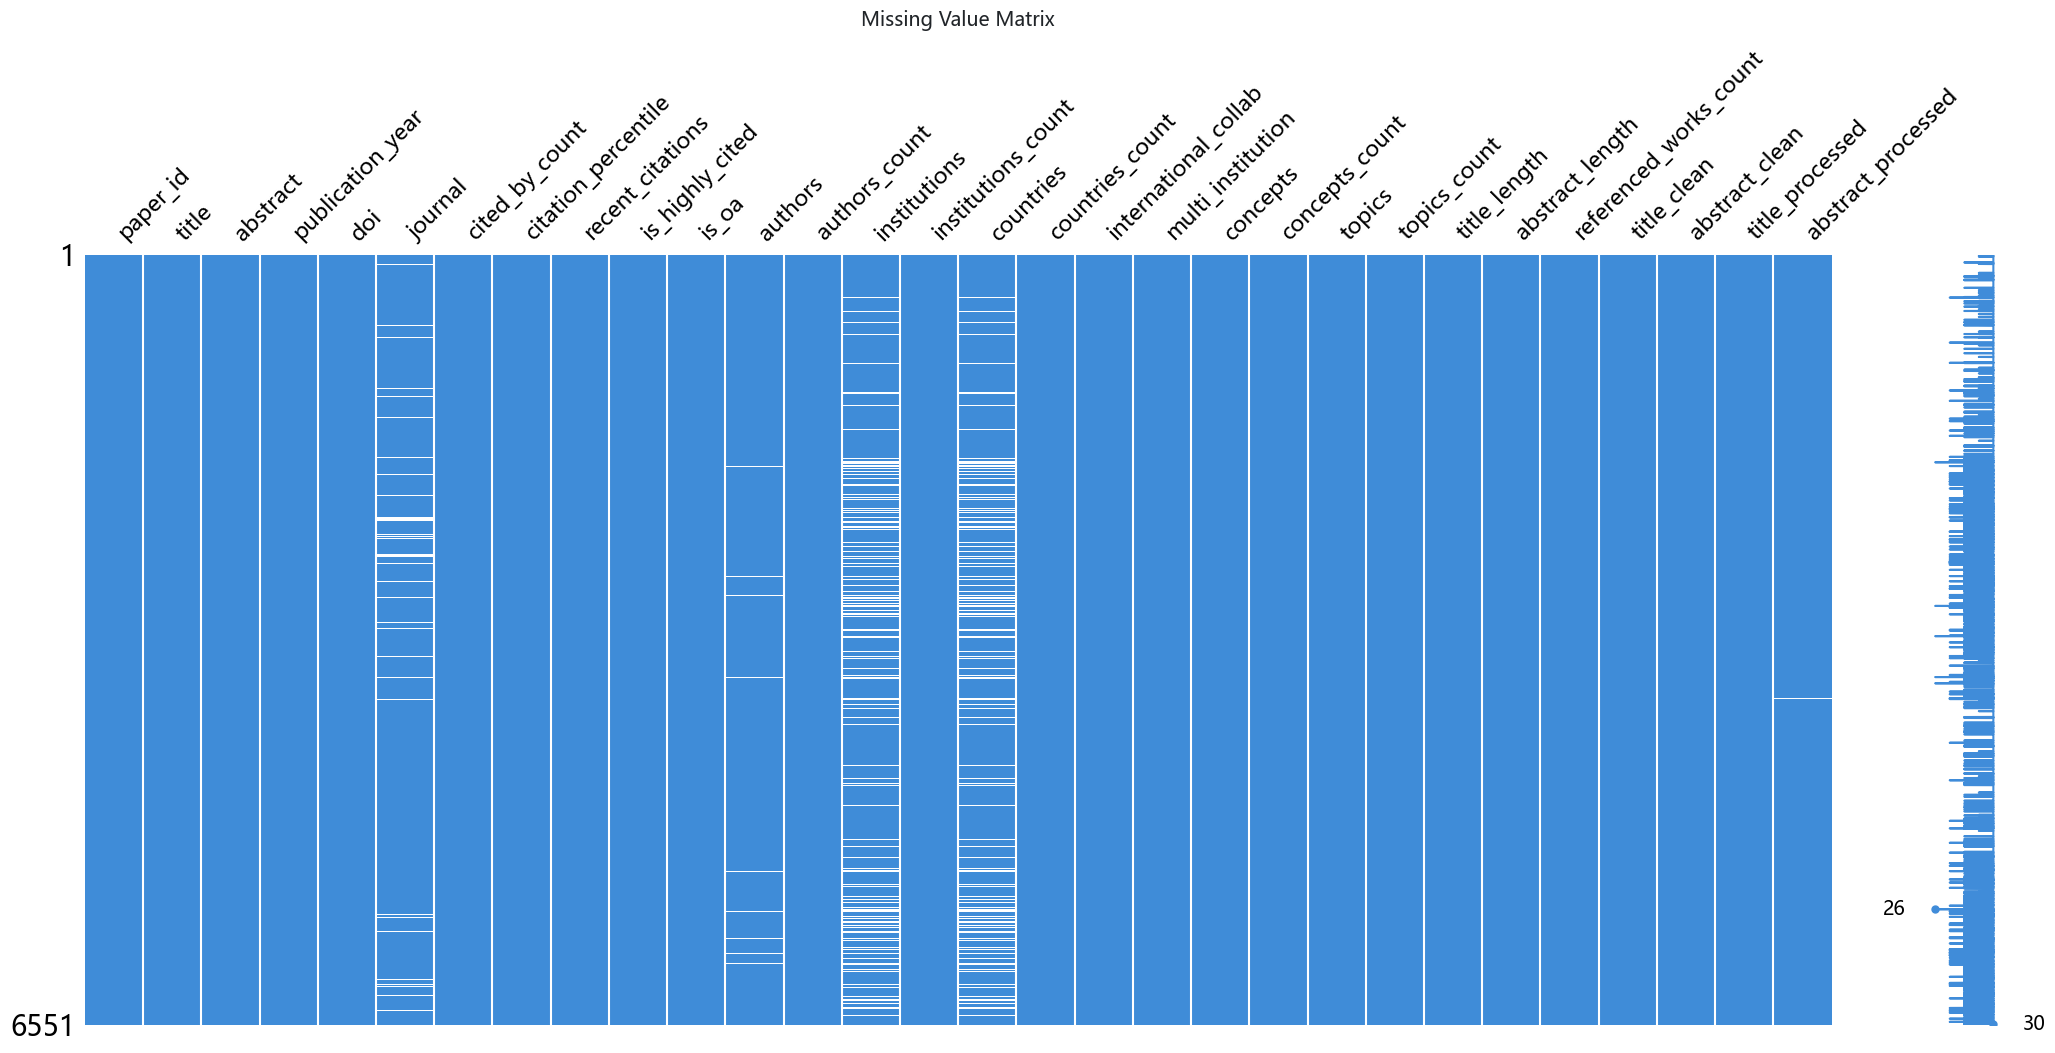


数据类型：
paper_id                      str
title                         str
abstract                      str
publication_year            int64
doi                           str
journal                       str
cited_by_count              int64
citation_percentile       float64
recent_citations            int64
is_highly_cited             int64
is_oa                       int64
authors                       str
authors_count               int64
institutions                  str
institutions_count          int64
countries                     str
countries_count             int64
international_collab        int64
multi_institution           int64
concepts                      str
concepts_count              int64
topics                        str
topics_count                int64
title_length                int64
abstract_length             int64
referenced_works_count      int64
title_clean                   str
abstract_clean                str
title_processed               str
abstrac

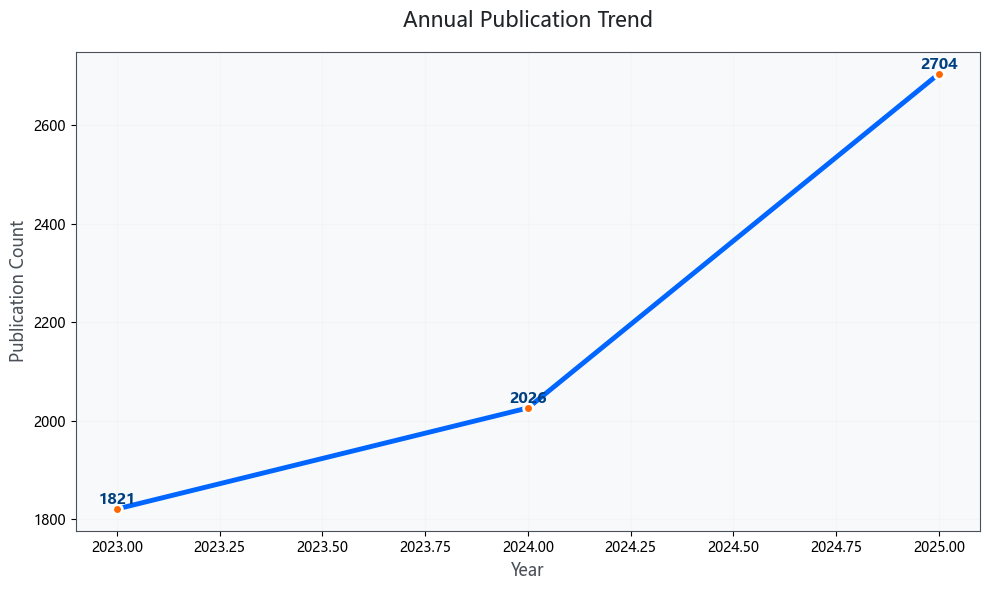

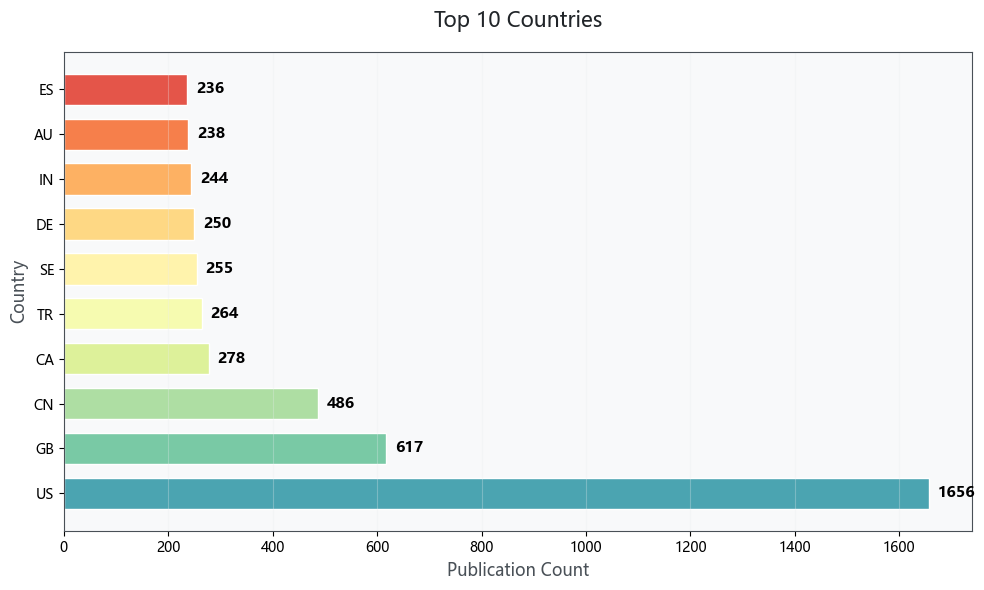

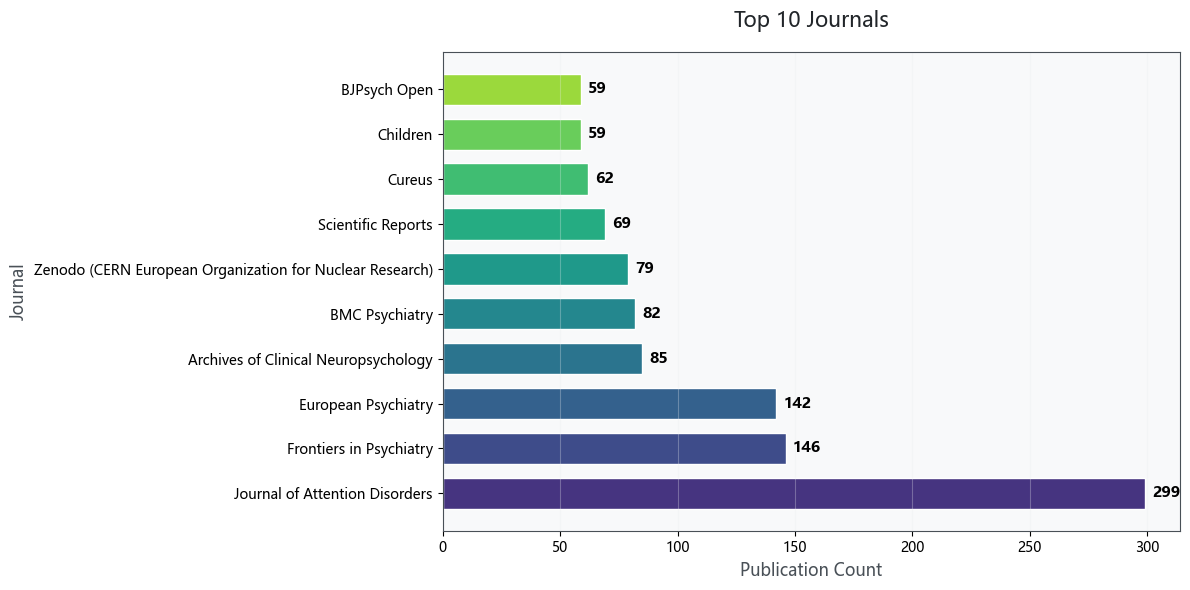

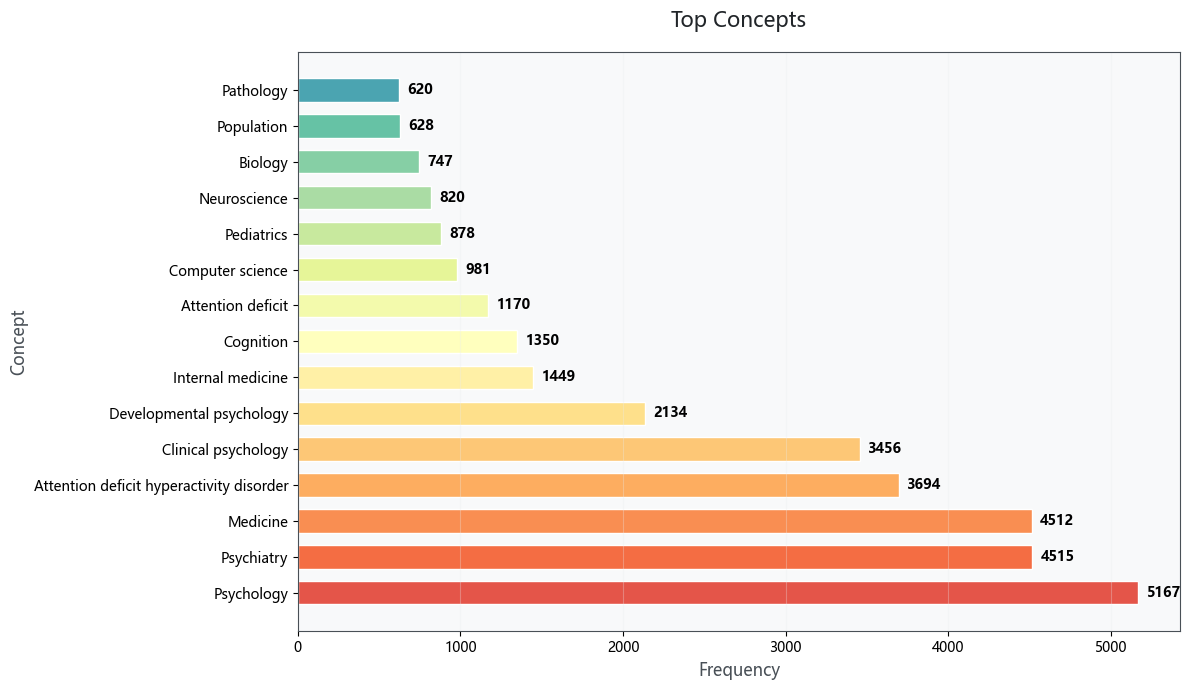

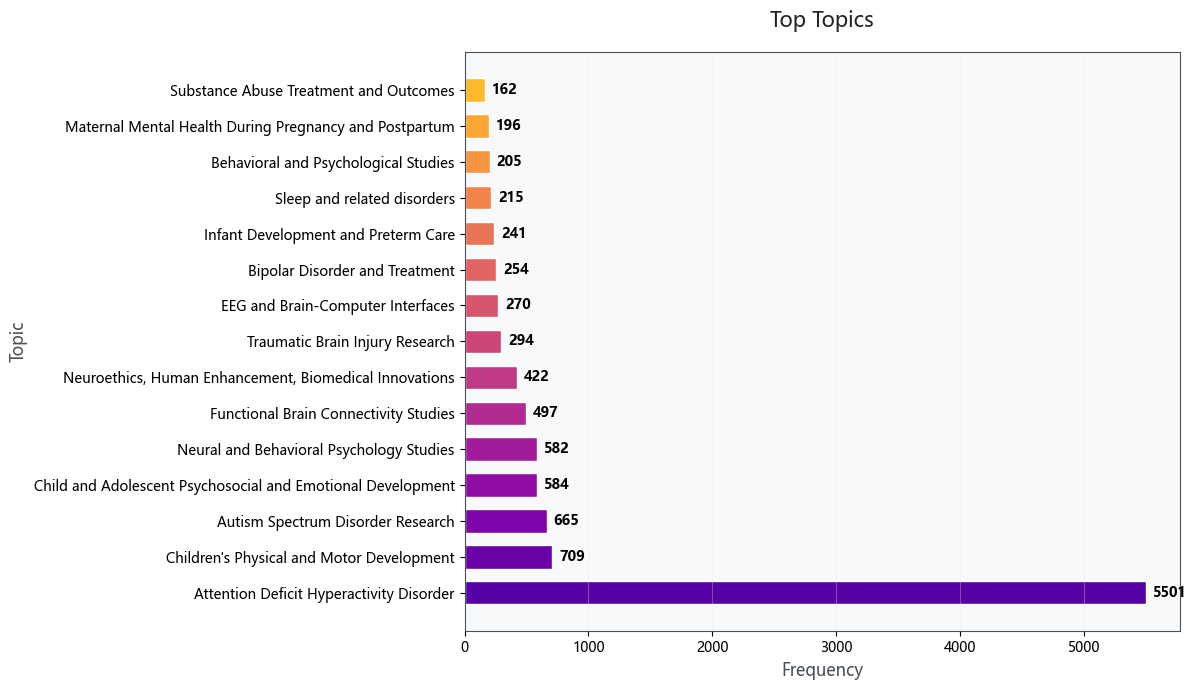

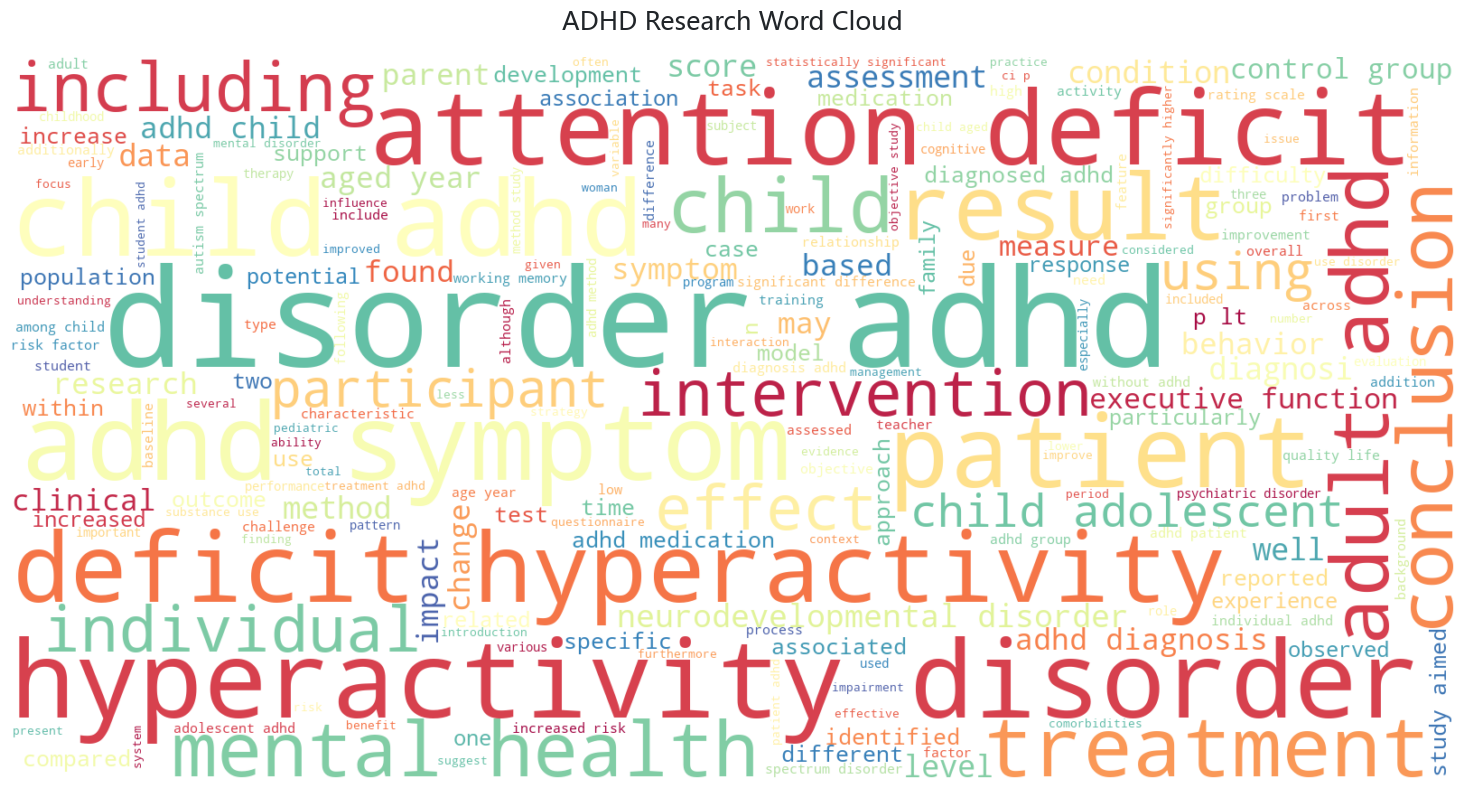

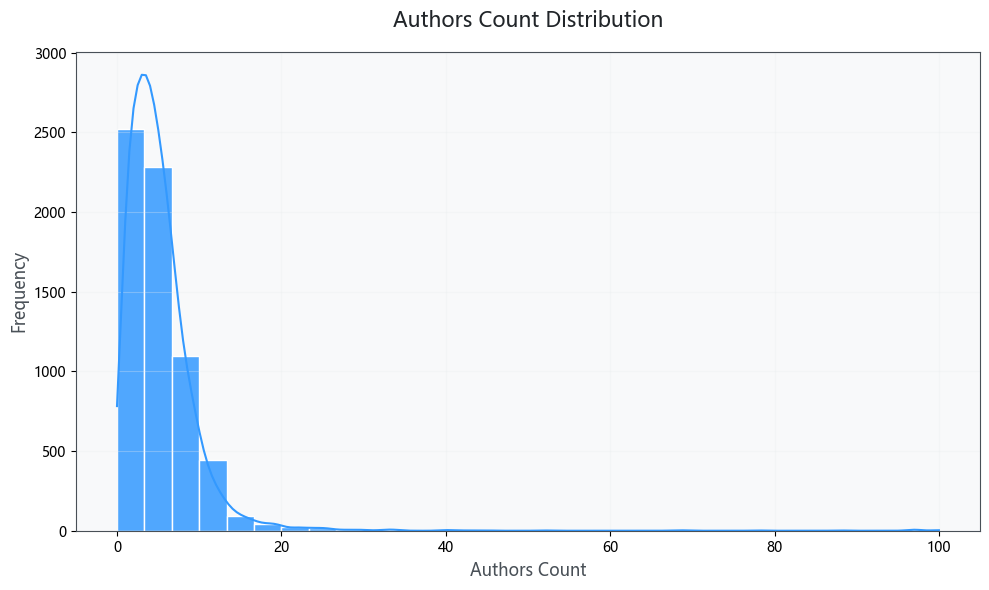

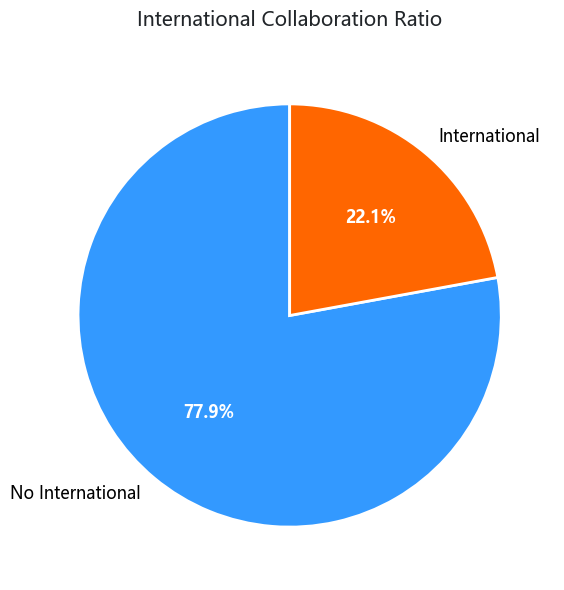

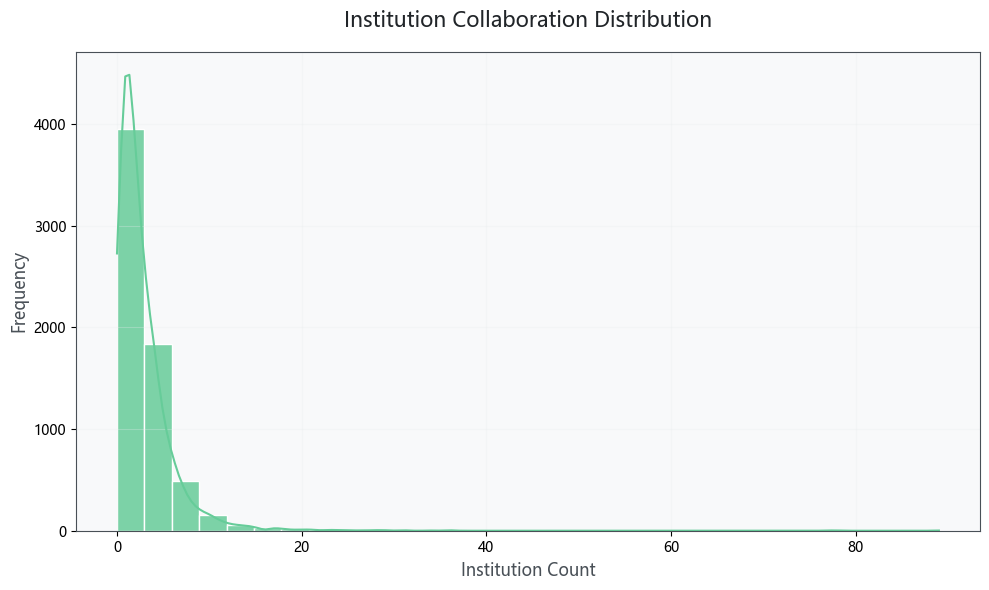

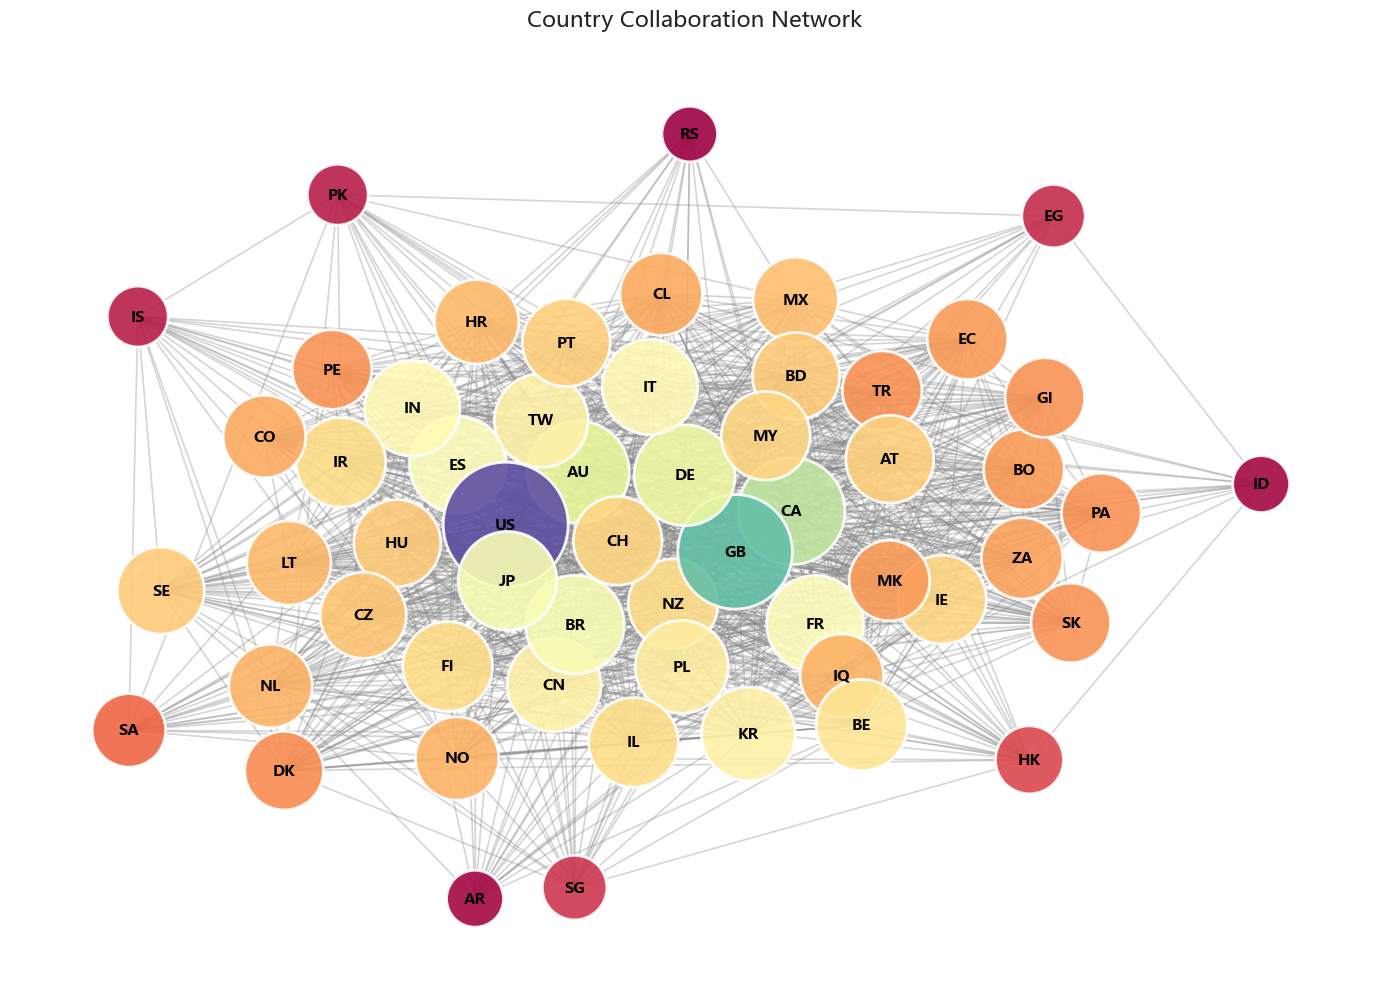


ADHD研究势态分析完成！


In [1]:
#ADHD研究势态分析
#一、导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import missingno as msno
import networkx as nx
#二、绘图风格设置
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei']
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.edgecolor'] = '#495057'
#三、读取数据
df = pd.read_csv(
    "ADHD_预处理后数据.csv"
)
print("数据维度：", df.shape)
print("\n字段：")
print(df.columns)
#四、数据质量分析
#1. 缺失值统计
missing = df.isnull().sum()
missing = missing[
    missing > 0
].sort_values(
    ascending=False
)
print("\n缺失值统计：")
print(missing)
#2. 缺失值可视化
plt.figure(figsize=(12,6), facecolor='white')
msno.matrix(df, color=(0.25, 0.55, 0.85))
plt.title("Missing Value Matrix", fontsize=14, pad=15, color='#212529')
plt.savefig("1_缺失值矩阵.png", dpi=300, bbox_inches='tight')
plt.show()
#3. 数据类型检查
print("\n数据类型：")
print(df.dtypes)
#五、研究发展态势分析
#1. 年度发文趋势
year_counts = df[
    "publication_year"
].value_counts().sort_index()
plt.figure(figsize=(10,6), facecolor='white')
plt.plot(year_counts.index, year_counts.values, color='#0066ff', linewidth=3.5, marker='o', markersize=7, markerfacecolor='#ff6600', markeredgecolor='white', markeredgewidth=2)
for x,y in zip(year_counts.index, year_counts.values):
    plt.text(x, y+10, str(y), ha='center', fontsize=11, fontweight='bold', color='#004080')
plt.title("Annual Publication Trend", fontsize=15, pad=18, color='#212529')
plt.xlabel("Year", fontsize=12, color='#495057')
plt.ylabel("Publication Count", fontsize=12, color='#495057')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("2_年度发文趋势.png", dpi=300, bbox_inches='tight')
plt.show()
#2. 国家发文量 Top10
country_list = []
for countries in df["countries"]:
    if pd.notna(countries):
        country_list.extend(
            str(countries).split("; ")
        )
country_counter = Counter(
    country_list
)
top_countries = pd.DataFrame(
    country_counter.items(),
    columns=["Country", "Count"]
).sort_values(
    by="Count",
    ascending=False
).head(10)
plt.figure(figsize=(10,6), facecolor='white')
colors = plt.cm.Spectral(np.linspace(0.15, 0.85, len(top_countries)))[::-1]
bars = plt.barh(top_countries['Country'], top_countries['Count'], color=colors, height=0.7, edgecolor='white', linewidth=1)
for idx, bar in enumerate(bars):
    val = top_countries['Count'].iloc[idx]
    plt.text(val + max(top_countries['Count'])*0.01, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold', fontsize=11)
plt.title("Top 10 Countries", fontsize=15, pad=18, color='#212529')
plt.xlabel("Publication Count", fontsize=12, color='#495057')
plt.ylabel("Country", fontsize=12, color='#495057')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("3_国家发文量TOP10.png", dpi=300, bbox_inches='tight')
plt.show()
#3. 核心期刊 Top10
top_journals = (
    df["journal"]
    .value_counts()
    .head(10)
)
plt.figure(figsize=(12,6), facecolor='white')
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(top_journals)))
bars = plt.barh(top_journals.index, top_journals.values, color=colors, height=0.7, edgecolor='white', linewidth=1)
for idx, bar in enumerate(bars):
    val = top_journals.values[idx]
    plt.text(val + max(top_journals.values)*0.01, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold', fontsize=11)
plt.title("Top 10 Journals", fontsize=15, pad=18, color='#212529')
plt.xlabel("Publication Count", fontsize=12, color='#495057')
plt.ylabel("Journal", fontsize=12, color='#495057')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("4_核心期刊TOP10.png", dpi=300, bbox_inches='tight')
plt.show()
#六、研究热点分析
#1. 高频 Concepts
concept_list = []
for concepts in df["concepts"]:
    if pd.notna(concepts):
        concept_list.extend(
            str(concepts).split("; ")
        )
concept_counter = Counter(
    concept_list
)
top_concepts = pd.DataFrame(
    concept_counter.items(),
    columns=["Concept", "Count"]
).sort_values(
    by="Count",
    ascending=False
).head(15)
plt.figure(figsize=(12,7), facecolor='white')
colors = plt.cm.Spectral(np.linspace(0.15, 0.85, len(top_concepts)))
bars = plt.barh(top_concepts['Concept'], top_concepts['Count'], color=colors, height=0.65, edgecolor='white', linewidth=1)
for idx, bar in enumerate(bars):
    val = top_concepts['Count'].iloc[idx]
    plt.text(val + max(top_concepts['Count'])*0.01, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold', fontsize=10)
plt.title("Top Concepts", fontsize=15, pad=18, color='#212529')
plt.xlabel("Frequency", fontsize=12, color='#495057')
plt.ylabel("Concept", fontsize=12, color='#495057')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("5_高频Concepts.png", dpi=300, bbox_inches='tight')
plt.show()
#2. 高频 Topics
topic_list = []
for topics in df["topics"]:
    if pd.notna(topics):
        topic_list.extend(
            str(topics).split("; ")
        )
topic_counter = Counter(
    topic_list
)
top_topics = pd.DataFrame(
    topic_counter.items(),
    columns=["Topic", "Count"]
).sort_values(
    by="Count",
    ascending=False
).head(15)
plt.figure(figsize=(12,7), facecolor='white')
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(top_topics)))
bars = plt.barh(top_topics['Topic'], top_topics['Count'], color=colors, height=0.65, edgecolor='white', linewidth=1)
for idx, bar in enumerate(bars):
    val = top_topics['Count'].iloc[idx]
    plt.text(val + max(top_topics['Count'])*0.01, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold', fontsize=10)
plt.title("Top Topics", fontsize=15, pad=18, color='#212529')
plt.xlabel("Frequency", fontsize=12, color='#495057')
plt.ylabel("Topic", fontsize=12, color='#495057')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("6_高频Topics.png", dpi=300, bbox_inches='tight')
plt.show()
#3. 词云分析
text = " ".join(
    df["abstract_processed"]
    .dropna()
)
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    colormap="Spectral",
    contour_width=1,
    contour_color="#dddddd"
).generate(text)
plt.figure(figsize=(16,8), facecolor='white')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("ADHD Research Word Cloud", fontsize=18, pad=20, color='#212529')
plt.tight_layout()
plt.savefig("7_研究热点词云.png", dpi=300, bbox_inches='tight')
plt.show()
#七、合作模式分析
#1. 作者数量分布
plt.figure(figsize=(10,6), facecolor='white')
sns.histplot(df["authors_count"], bins=30, kde=True, color='#3399ff', alpha=0.85, edgecolor='white', linewidth=1)
plt.title("Authors Count Distribution", fontsize=15, pad=18, color='#212529')
plt.xlabel("Authors Count", fontsize=12, color='#495057')
plt.ylabel("Frequency", fontsize=12, color='#495057')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("8_作者数量分布.png", dpi=300, bbox_inches='tight')
plt.show()
#2. 国际合作比例
collab_counts = (
    df["international_collab"]
    .value_counts()
)
plt.figure(figsize=(6,6), facecolor='white')
colors = ['#3399ff', '#ff6600']
wedges, texts, autotexts = plt.pie(collab_counts.values, labels=['No International', 'International'], autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize':12}, wedgeprops={'edgecolor':'white','linewidth':2})
for autot in autotexts:
    autot.set_color('white')
    autot.set_fontweight('bold')
plt.title("International Collaboration Ratio", fontsize=14, pad=18, color='#212529')
plt.tight_layout()
plt.savefig("9_国际合作比例.png", dpi=300, bbox_inches='tight')
plt.show()
#3. 机构合作分布
plt.figure(figsize=(10,6), facecolor='white')
sns.histplot(df["institutions_count"], bins=30, kde=True, color='#66cc99', alpha=0.85, edgecolor='white', linewidth=1)
plt.title("Institution Collaboration Distribution", fontsize=15, pad=18, color='#212529')
plt.xlabel("Institution Count", fontsize=12, color='#495057')
plt.ylabel("Frequency", fontsize=12, color='#495057')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("10_机构合作分布.png", dpi=300, bbox_inches='tight')
plt.show()
#八、国家合作网络
G = nx.Graph()
for countries in df["countries"]:
    if pd.notna(countries):
        country_nodes = list(set(
            str(countries).split("; ")
        ))
        # 两两连边
        for i in range(
            len(country_nodes)
        ):
            for j in range(
                i + 1,
                len(country_nodes)
            ):
                G.add_edge(
                    country_nodes[i],
                    country_nodes[j]
                )
# 仅保留主要节点
top_nodes = [
    node for node, degree
    in dict(G.degree()).items()
    if degree >= 20
]
subgraph = G.subgraph(
    top_nodes
)
plt.figure(figsize=(14,10), facecolor='white')
pos = nx.spring_layout(subgraph, seed=42, k=2)
node_sizes = [dict(G.degree())[n]*80 for n in subgraph.nodes()]
node_colors = [dict(G.degree())[n] for n in subgraph.nodes()]
nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.Spectral, edgecolors='white', linewidths=2, alpha=0.9)
nx.draw_networkx_edges(subgraph, pos, alpha=0.35, edge_color='#888888', width=1.2)
nx.draw_networkx_labels(subgraph, pos, font_size=11, font_weight='bold', font_family='sans-serif')
plt.title("Country Collaboration Network", fontsize=16, pad=20, color='#212529')
plt.axis("off")
plt.tight_layout()
plt.savefig("11_国家合作网络.png", dpi=300, bbox_inches='tight')
plt.show()
#九、EDA完成
print("\nADHD研究势态分析完成！")

数据维度： (6551, 30)

高被引阈值： 8.0


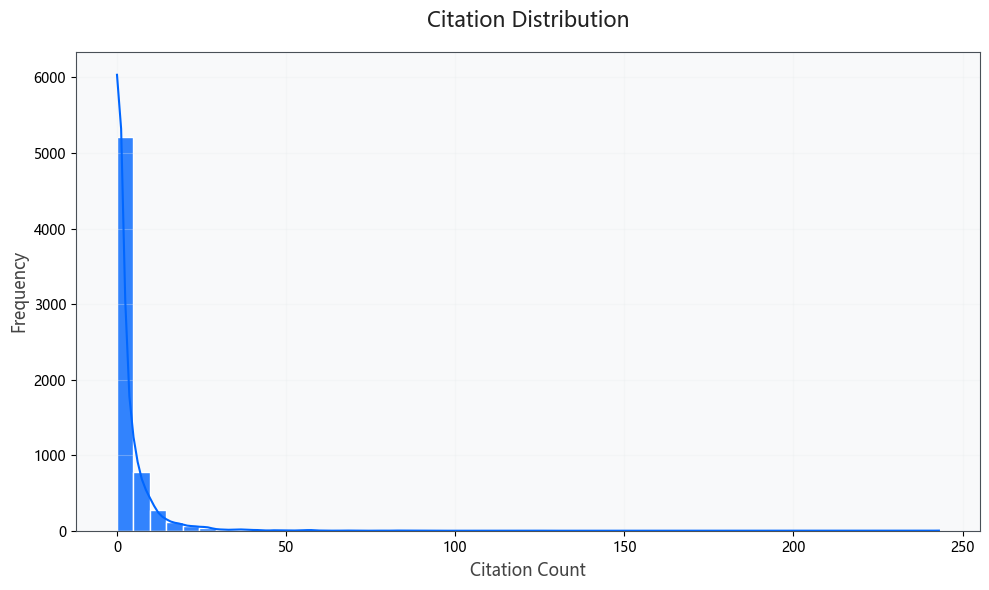

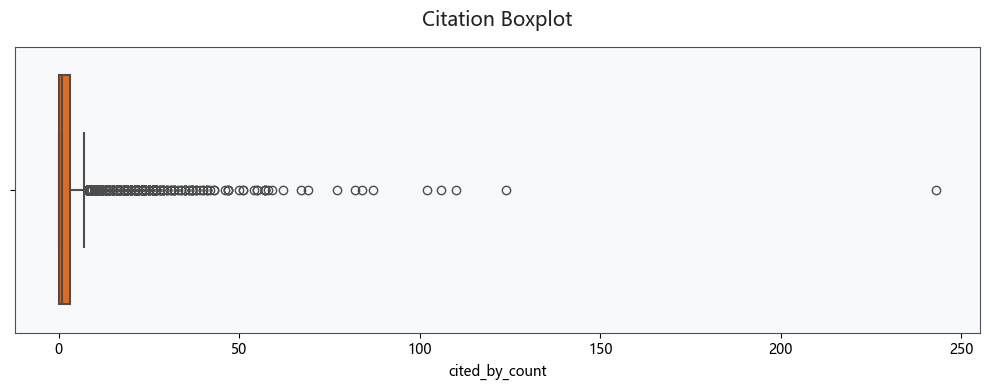

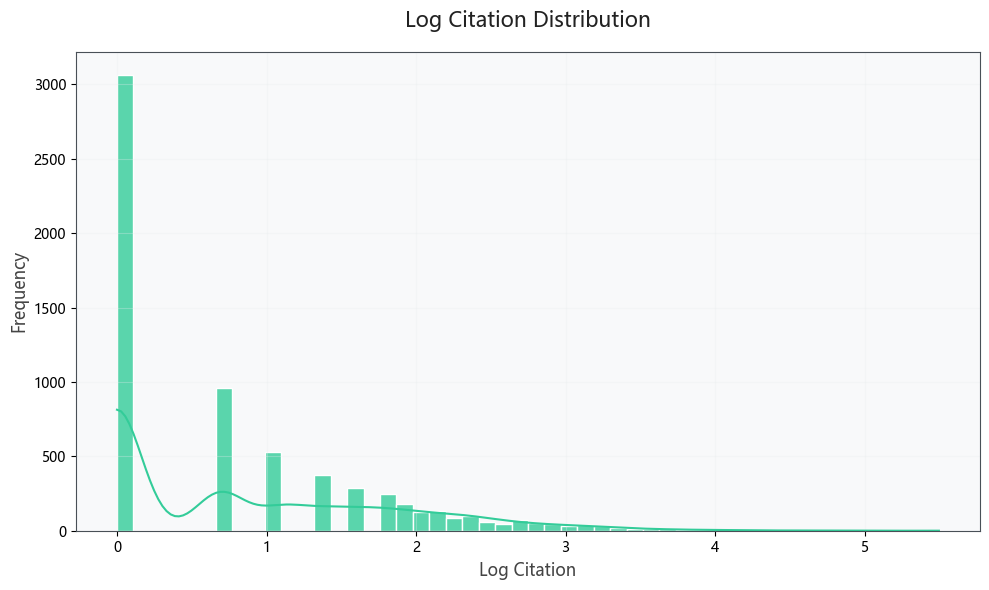

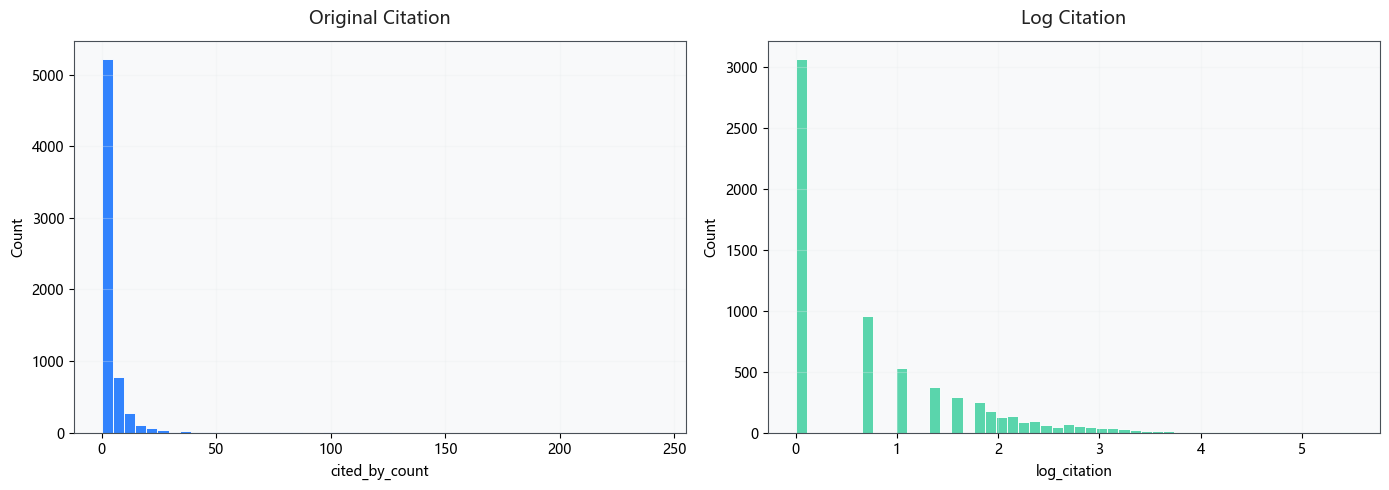

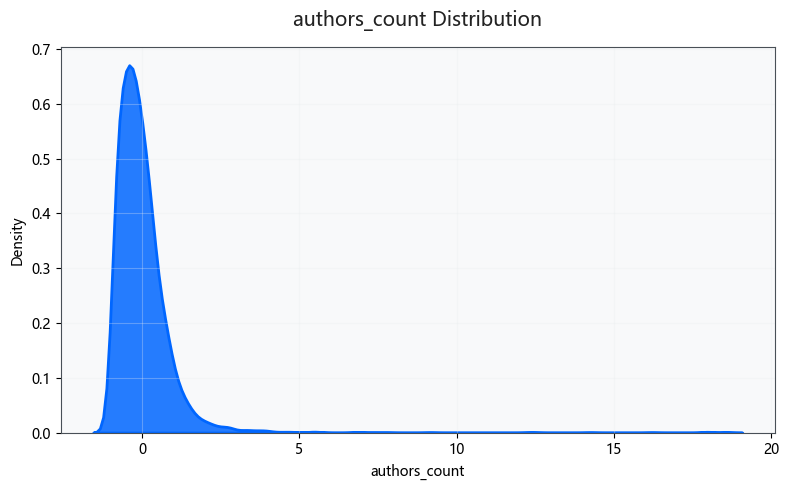

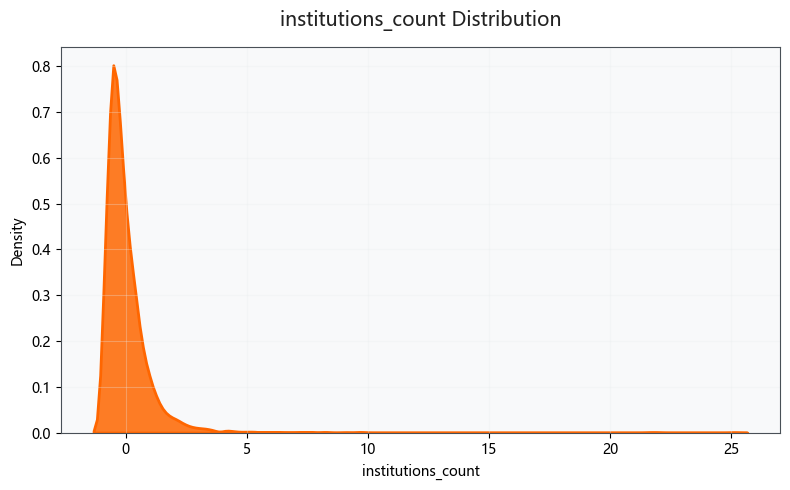

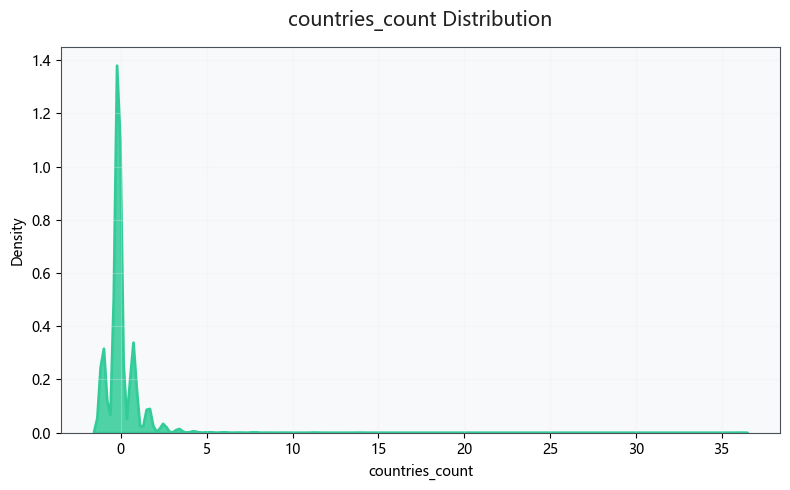

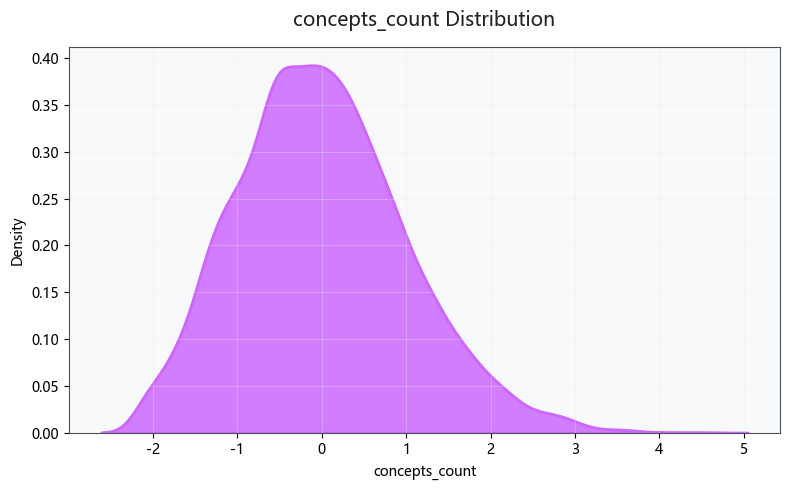

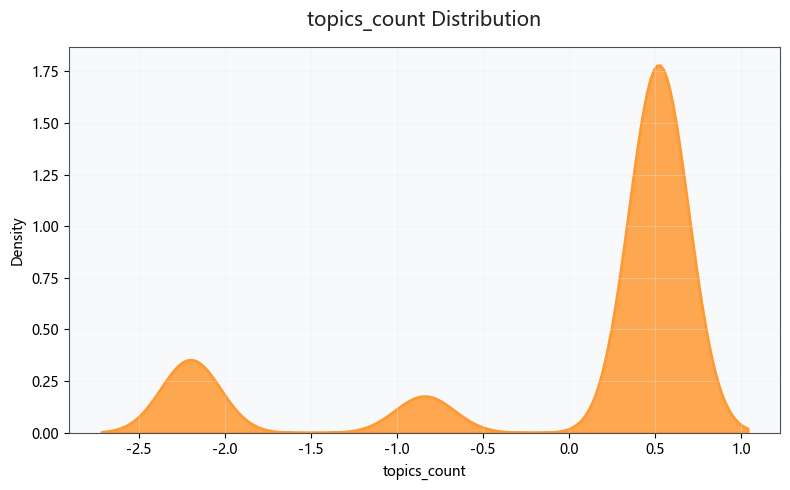

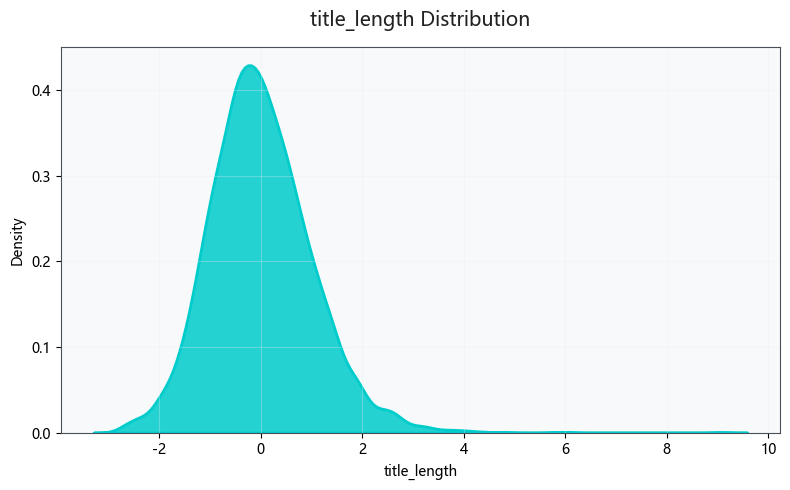

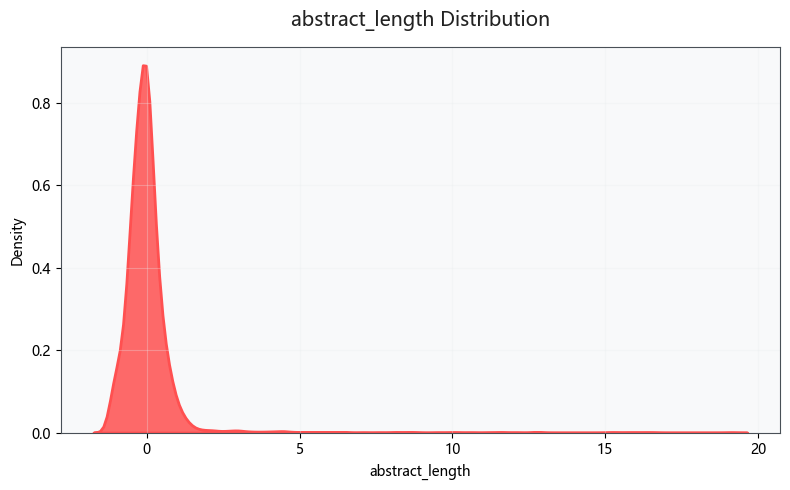

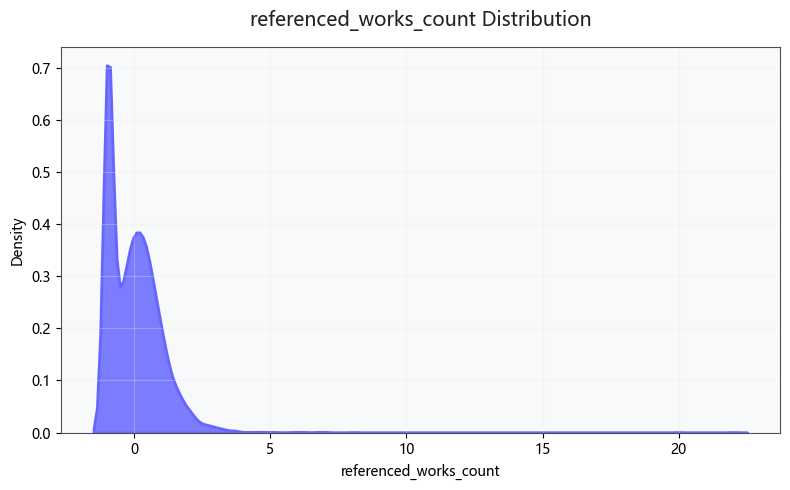

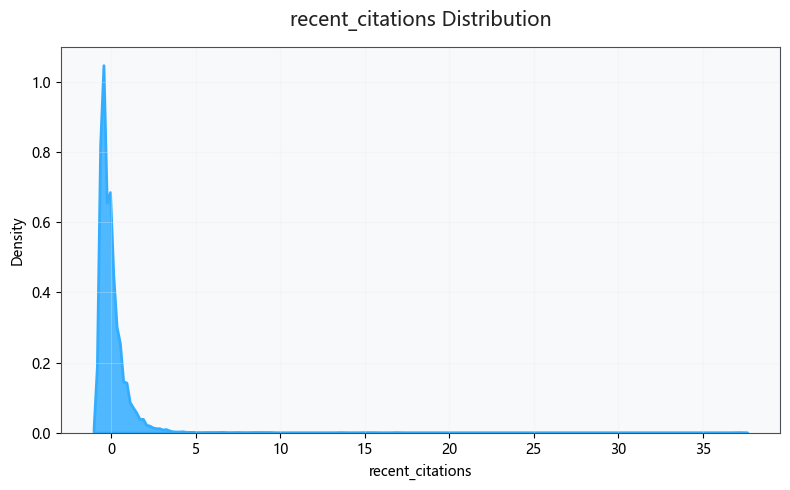

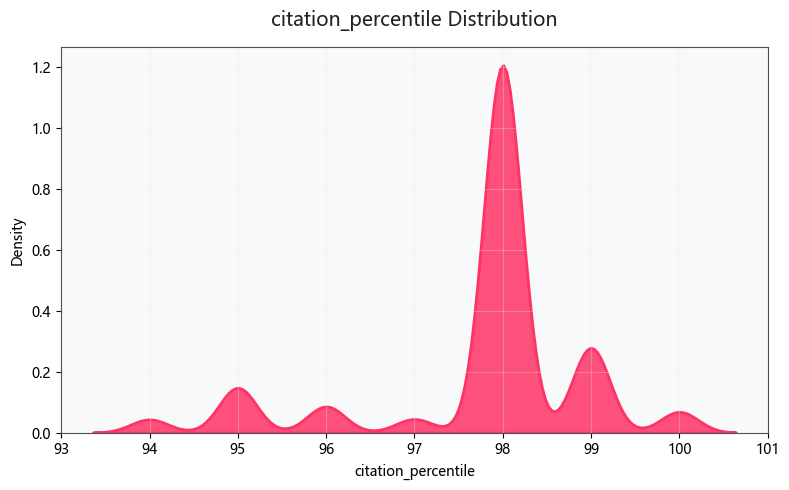

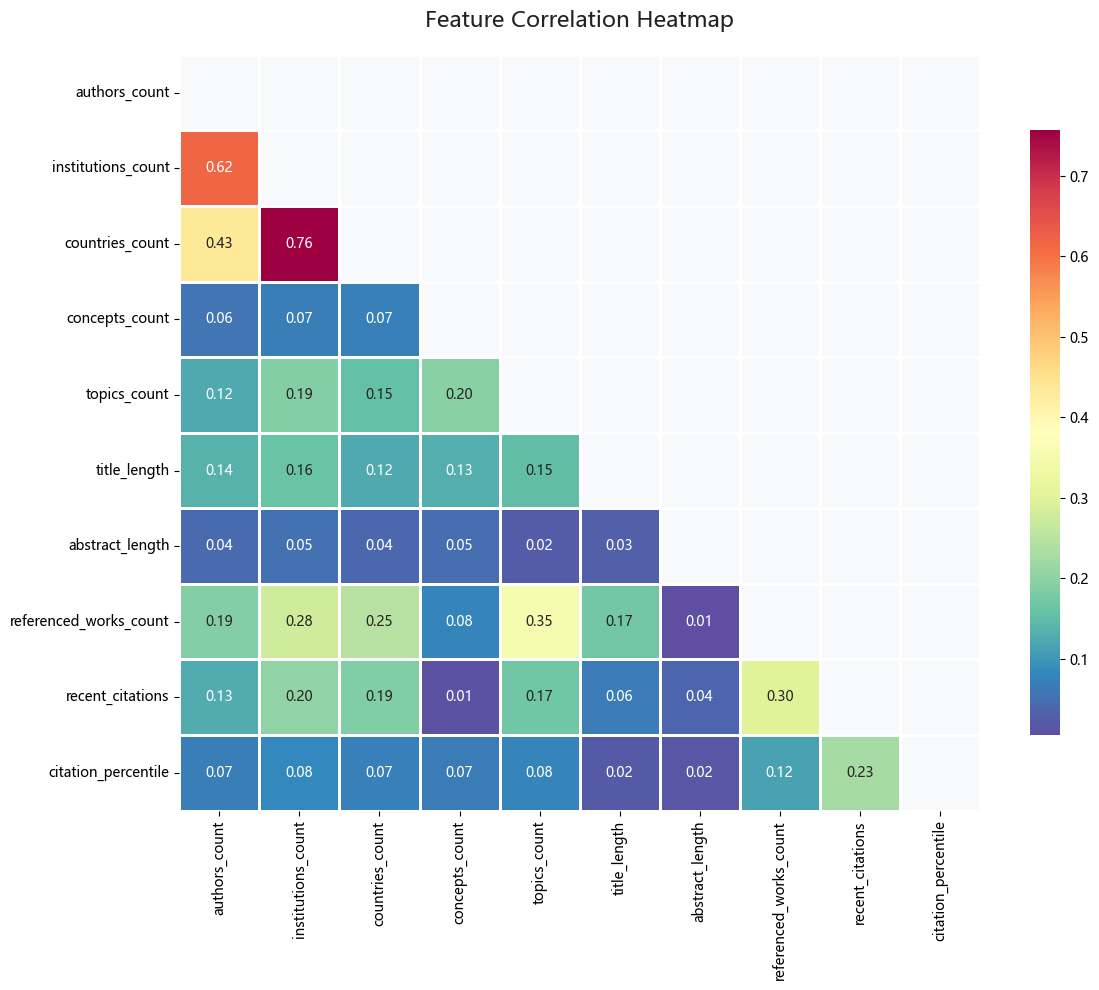

C:\Users\21116\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\21116\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\21116\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\21116\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
C:\Users\21116\AppData\Roaming\Python\Python313\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
C:\Users\21116\AppDa

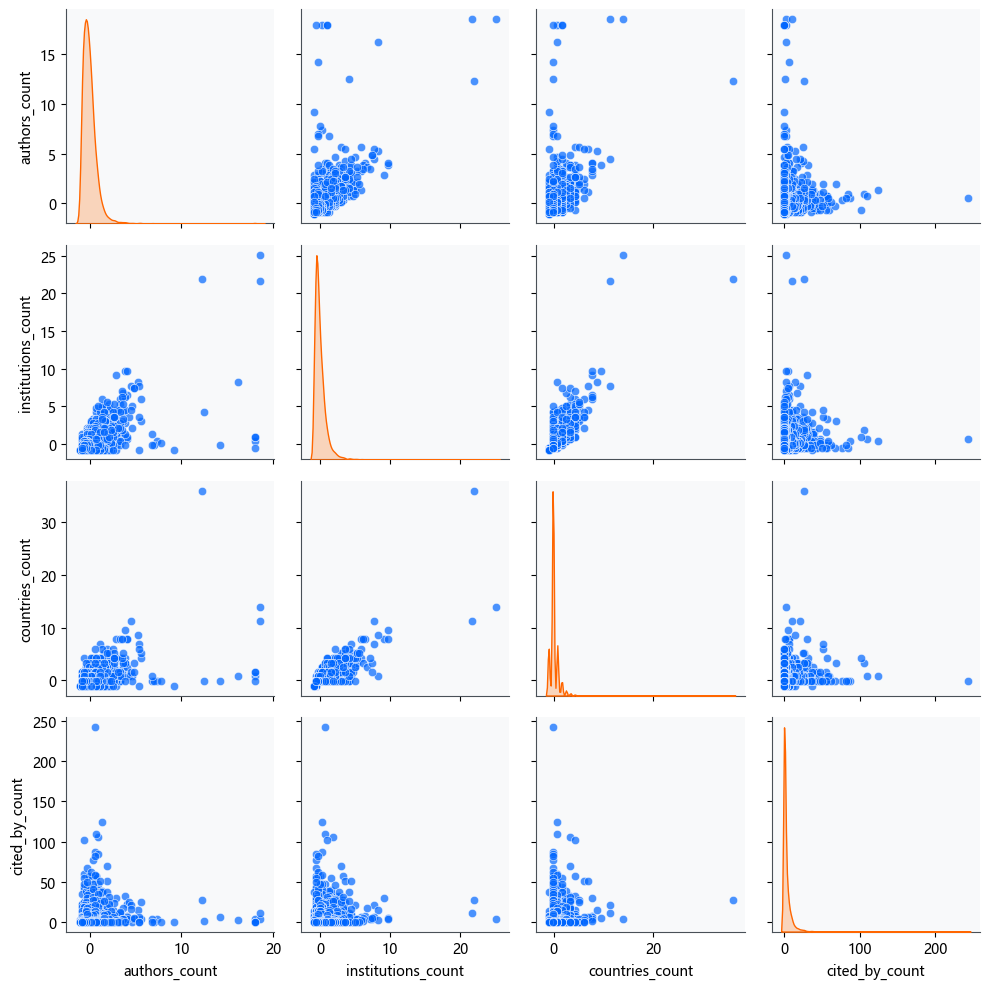

C:\Users\21116\AppData\Local\Temp\ipykernel_36244\1288526992.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="highly_cited", y=feature, data=df, palette=box_colors, linewidth=1.5)


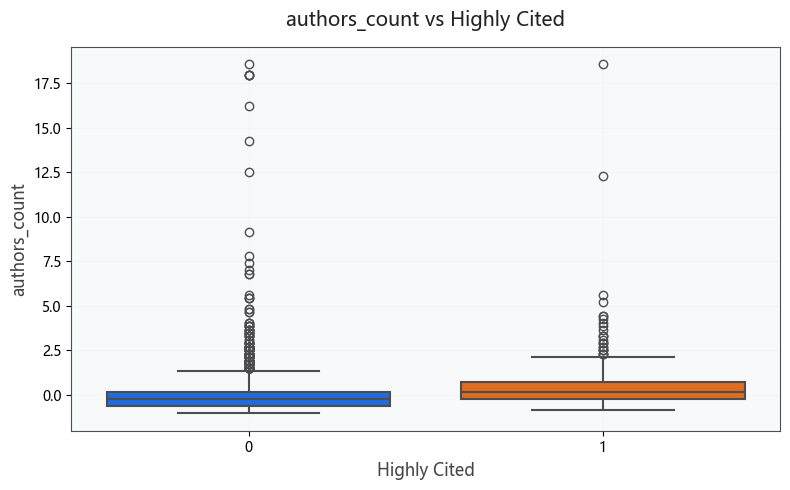

C:\Users\21116\AppData\Local\Temp\ipykernel_36244\1288526992.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="highly_cited", y=feature, data=df, palette=box_colors, linewidth=1.5)


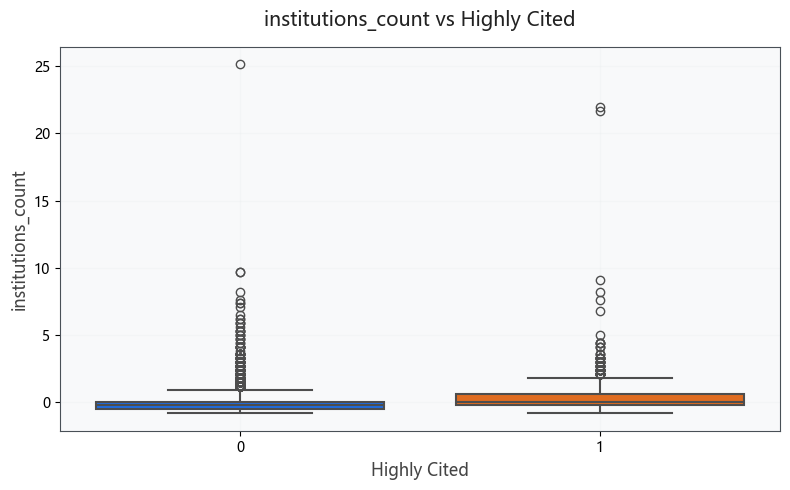

C:\Users\21116\AppData\Local\Temp\ipykernel_36244\1288526992.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="highly_cited", y=feature, data=df, palette=box_colors, linewidth=1.5)


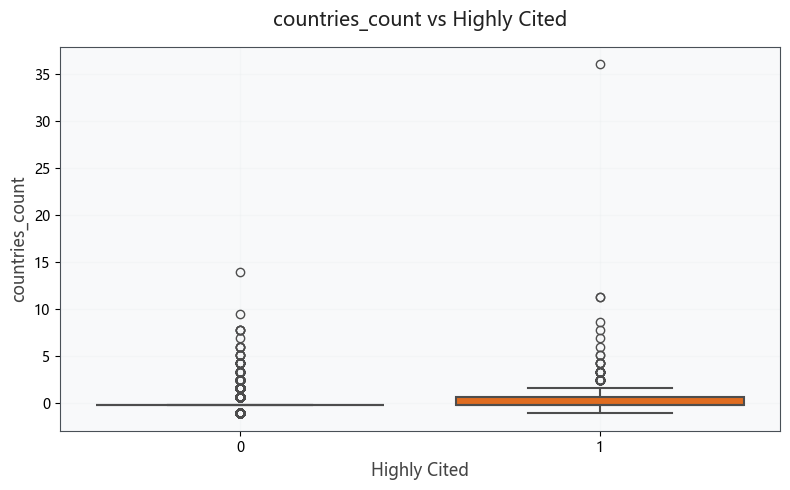

C:\Users\21116\AppData\Local\Temp\ipykernel_36244\1288526992.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="highly_cited", y=feature, data=df, palette=box_colors, linewidth=1.5)


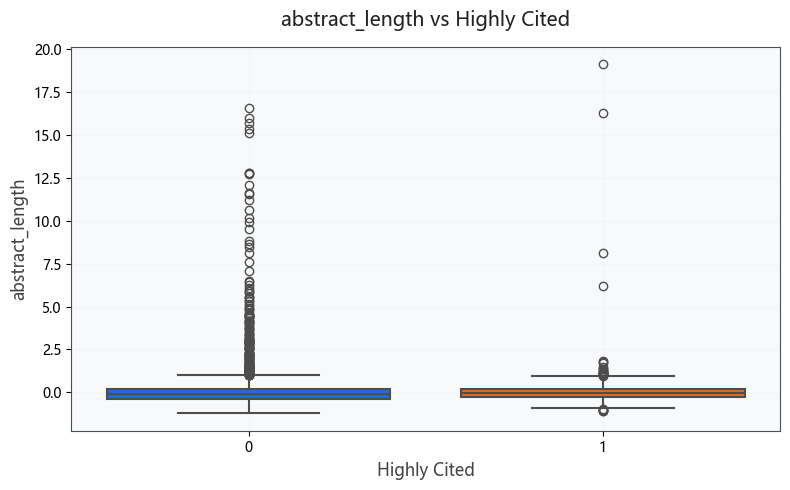

C:\Users\21116\AppData\Local\Temp\ipykernel_36244\1288526992.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="highly_cited", y=feature, data=df, palette=box_colors, linewidth=1.5)


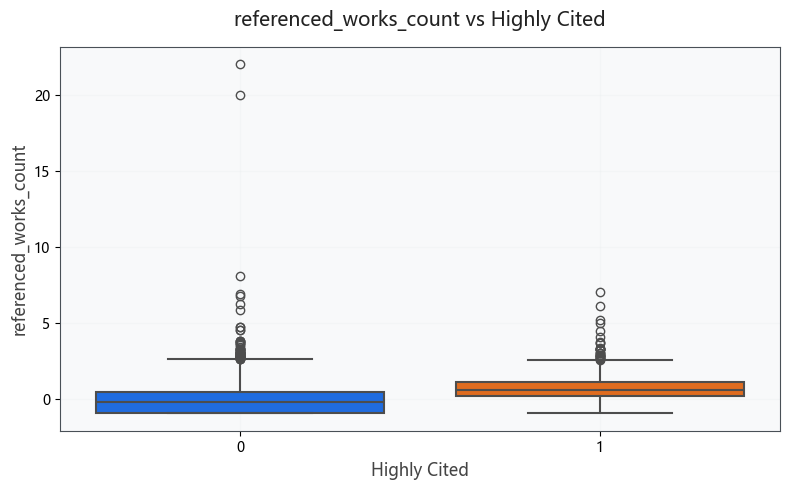

C:\Users\21116\AppData\Local\Temp\ipykernel_36244\1288526992.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="highly_cited", y=feature, data=df, palette=box_colors, linewidth=1.5)


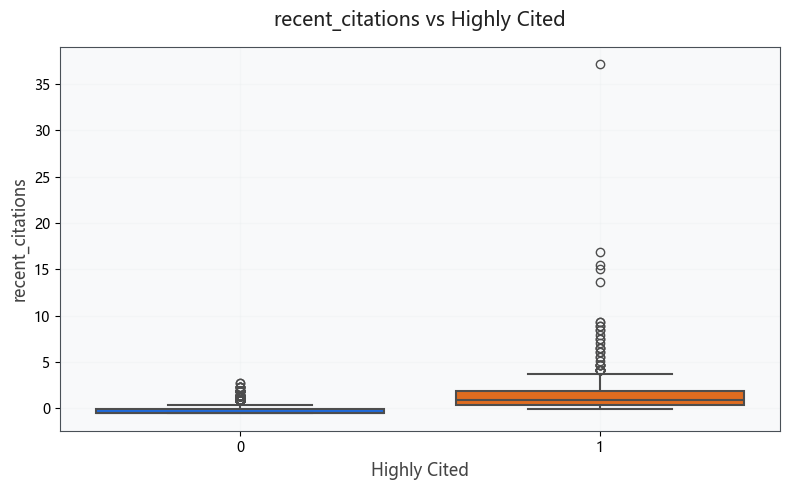

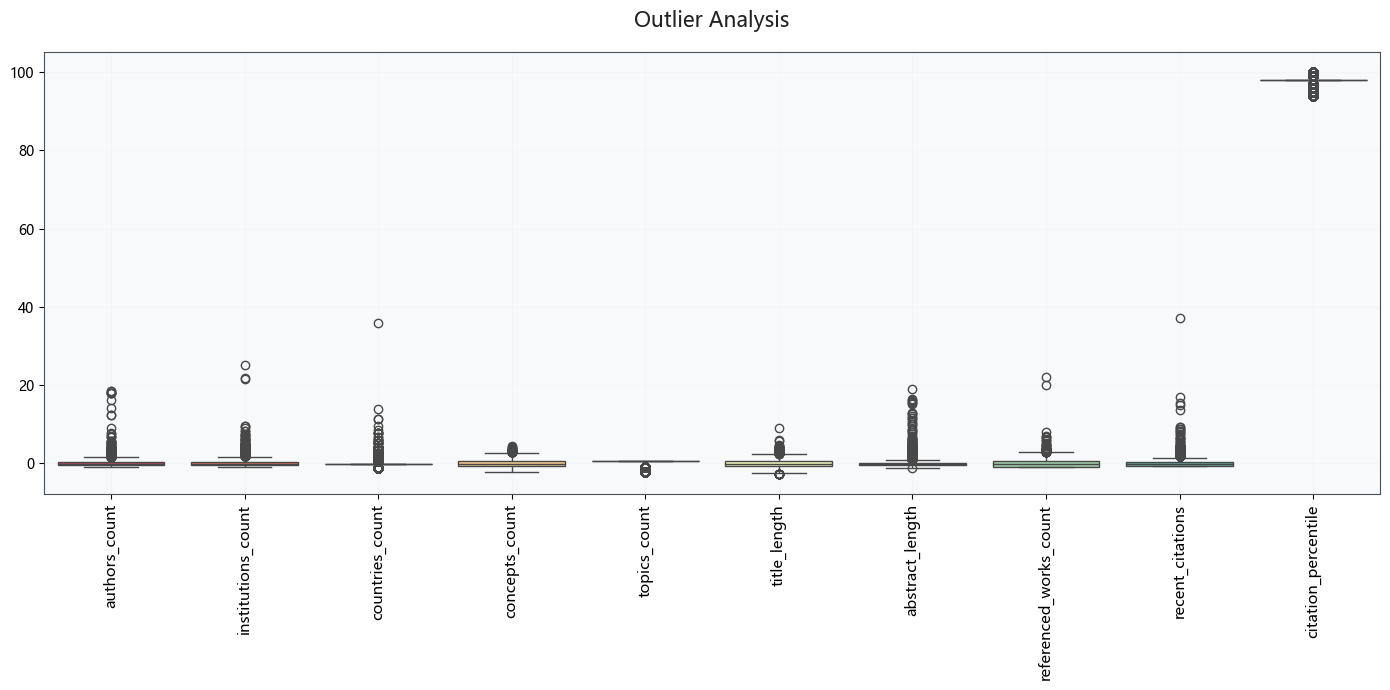

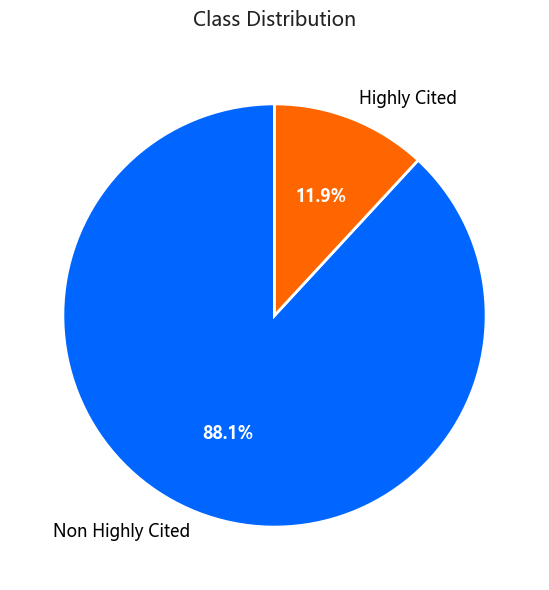

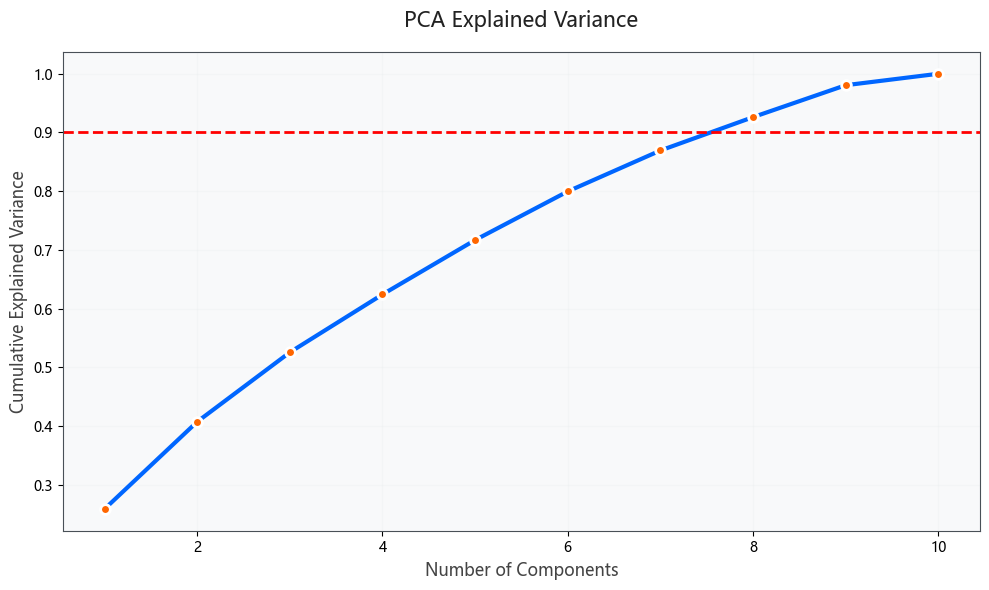

C:\Users\21116\AppData\Local\Temp\ipykernel_36244\1288526992.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors_bar, edgecolor='white', linewidth=1)
C:\Users\21116\AppData\Local\Temp\ipykernel_36244\1288526992.py:185: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors_bar, edgecolor='white', linewidth=1)


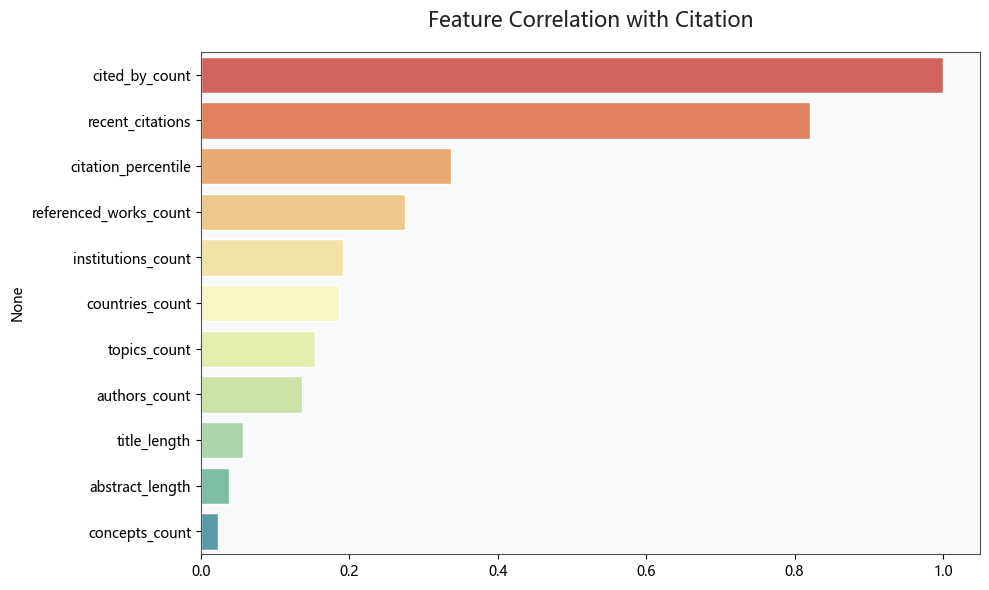


ADHD 机器学习EDA完成！


In [2]:
#ADHD 机器学习EDA
#一、导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
#二、绘图风格
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei']
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.linewidth'] = 0.8
#三、读取数据
df = pd.read_csv(
    "ADHD_标准化数据.csv"
)
print("数据维度：", df.shape)
#四、构建高被引标签
threshold = df[
    "cited_by_count"
].quantile(0.9)
df["highly_cited"] = (
    df["cited_by_count"]
    >= threshold
).astype(int)
print(
    "\n高被引阈值：",
    threshold
)
#五、引用分布分析（关键）
#1. 原始引用分布
plt.figure(figsize=(10,6), facecolor='white')
sns.histplot(df["cited_by_count"], bins=50, kde=True, color='#0066ff', alpha=0.8, edgecolor='white', linewidth=1)
plt.title("Citation Distribution", fontsize=15, pad=18, color='#222')
plt.xlabel("Citation Count", fontsize=12, color='#444')
plt.ylabel("Frequency", fontsize=12, color='#444')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("01_原始引用分布.png", dpi=300, bbox_inches='tight')
plt.show()
#2. 引用箱线图
plt.figure(figsize=(10,4), facecolor='white')
sns.boxplot(x=df["cited_by_count"], color='#ff6600', linewidth=1.5)
plt.title("Citation Boxplot", fontsize=14, pad=15, color='#222')
plt.tight_layout()
plt.savefig("02_引用箱线图.png", dpi=300, bbox_inches='tight')
plt.show()
#六、Log 变换分析（重要）
# 构建 log 引用
df["log_citation"] = np.log1p(df["cited_by_count"])
#1. Log后分布
plt.figure(figsize=(10,6), facecolor='white')
sns.histplot(df["log_citation"], bins=50, kde=True, color='#33cc99', alpha=0.8, edgecolor='white', linewidth=1)
plt.title("Log Citation Distribution", fontsize=15, pad=18, color='#222')
plt.xlabel("Log Citation", fontsize=12, color='#444')
plt.ylabel("Frequency", fontsize=12, color='#444')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("03_Log引用分布.png", dpi=300, bbox_inches='tight')
plt.show()
#2. 原始 vs Log 对比
fig, axes = plt.subplots(1,2, figsize=(14,5), facecolor='white')
sns.histplot(df["cited_by_count"], bins=50, color='#0066ff', alpha=0.8, edgecolor='white', ax=axes[0])
axes[0].set_title("Original Citation", fontsize=13, pad=12, color='#222')
axes[0].grid(alpha=0.3)
sns.histplot(df["log_citation"], bins=50, color='#33cc99', alpha=0.8, edgecolor='white', ax=axes[1])
axes[1].set_title("Log Citation", fontsize=13, pad=12, color='#222')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("04_原始vsLog引用对比.png", dpi=300, bbox_inches='tight')
plt.show()
#七、数值变量分布分析
numeric_features = [
    "authors_count",
    "institutions_count",
    "countries_count",
    "concepts_count",
    "topics_count",
    "title_length",
    "abstract_length",
    "referenced_works_count",
    "recent_citations",
    "citation_percentile"
]
#KDE 分布图
colors_kde = ['#0066ff','#ff6600','#33cc99','#cc66ff','#ff9933','#00cccc','#ff5050','#6666ff','#33adff','#ff3366']
for i, feature in enumerate(numeric_features):
    plt.figure(figsize=(8,5), facecolor='white')
    sns.kdeplot(df[feature], fill=True, color=colors_kde[i%len(colors_kde)], alpha=0.85, linewidth=2)
    plt.title(f"{feature} Distribution", fontsize=14, pad=15, color='#222')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"05_{i+1}_{feature}分布.png", dpi=300, bbox_inches='tight')
    plt.show()
#八、相关性分析（PCA关键）
#1. 相关性矩阵
corr = df[numeric_features].corr()
#2. 高级热力图
mask = np.triu(np.ones_like(corr))
plt.figure(figsize=(12,10), facecolor='white')
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Spectral_r", mask=mask, linewidths=0.8, linecolor='white', cbar_kws={'shrink':0.8})
plt.title("Feature Correlation Heatmap", fontsize=16, pad=20, color='#222')
plt.tight_layout()
plt.savefig("06_特征相关性热力图.png", dpi=300, bbox_inches='tight')
plt.show()
#九、Pairplot（高级）
pair_features = [
    "authors_count",
    "institutions_count",
    "countries_count",
    "cited_by_count"
]
g = sns.pairplot(df[pair_features], diag_kind="kde", palette='Spectral', plot_kws={'color':'#0066ff','alpha':0.7}, diag_kws={'color':'#ff6600','fill':True})
g.fig.set_facecolor('white')
plt.tight_layout()
plt.savefig("07_特征配对图.png", dpi=300, bbox_inches='tight')
plt.show()
#十、高被引论文特征分析（关键）
compare_features = [
    "authors_count",
    "institutions_count",
    "countries_count",
    "abstract_length",
    "referenced_works_count",
    "recent_citations"
]
#箱线图比较
box_colors = ['#0066ff','#ff6600']
for i, feature in enumerate(compare_features):
    plt.figure(figsize=(8,5), facecolor='white')
    sns.boxplot(x="highly_cited", y=feature, data=df, palette=box_colors, linewidth=1.5)
    plt.title(f"{feature} vs Highly Cited", fontsize=14, pad=15, color='#222')
    plt.xlabel("Highly Cited", fontsize=12, color='#444')
    plt.ylabel(feature, fontsize=12, color='#444')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"E08_{i+1}_{feature}_高被引对比.png", dpi=300, bbox_inches='tight')
    plt.show()
#十一、异常值分析
#箱线图（所有变量）
plt.figure(figsize=(14,7), facecolor='white')
sns.boxplot(data=df[numeric_features], palette='Spectral', linewidth=1)
plt.xticks(rotation=90, fontsize=11)
plt.title("Outlier Analysis", fontsize=15, pad=18, color='#222')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("09_多变量异常值分析.png", dpi=300, bbox_inches='tight')
plt.show()
#十二、类别平衡分析
class_counts = df["highly_cited"].value_counts()
plt.figure(figsize=(6,6), facecolor='white')
colors_pie = ['#0066ff','#ff6600']
wedges, texts, autotexts = plt.pie(class_counts.values, labels=["Non Highly Cited","Highly Cited"], autopct="%1.1f%%", colors=colors_pie, startangle=90, textprops={'fontsize':12}, wedgeprops={'edgecolor':'white','linewidth':2})
for autot in autotexts:
    autot.set_color('white')
    autot.set_fontweight('bold')
plt.title("Class Distribution", fontsize=14, pad=18, color='#222')
plt.tight_layout()
plt.savefig("010_高被引类别平衡.png", dpi=300, bbox_inches='tight')
plt.show()
#十三、PCA 前置分析（关键）
#1. PCA
pca = PCA()
pca.fit(df[numeric_features])
#2. 累积解释方差
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10,6), facecolor='white')
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker="o", markersize=7, color='#0066ff', linewidth=3, markerfacecolor='#ff6600', markeredgecolor='white', markeredgewidth=2)
plt.axhline(y=0.9, color="red", linestyle="--", linewidth=2)
plt.xlabel("Number of Components", fontsize=12, color='#444')
plt.ylabel("Cumulative Explained Variance", fontsize=12, color='#444')
plt.title("PCA Explained Variance", fontsize=15, pad=18, color='#222')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("011_PCA解释方差.png", dpi=300, bbox_inches='tight')
plt.show()
#十四、特征重要性初步观察
corr_target = df[numeric_features + ["cited_by_count"]].corr()["cited_by_count"]
corr_target = corr_target.sort_values(ascending=False)
plt.figure(figsize=(10,6), facecolor='white')
colors_bar = plt.cm.Spectral(np.linspace(0.15, 0.85, len(corr_target)))
sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors_bar, edgecolor='white', linewidth=1)
plt.title("Feature Correlation with Citation", fontsize=15, pad=18, color='#222')
plt.tight_layout()
plt.savefig("012_特征与引用相关性.png", dpi=300, bbox_inches='tight')
plt.show()
#十五、ADHD 机器学习EDA完成
print("\nADHD 机器学习EDA完成！")